P.K.M.P. KUMARA
230353N 

1. Implement the intensity transformation

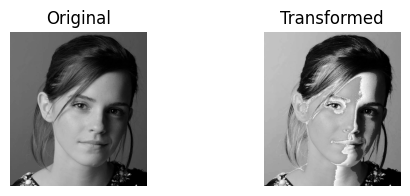

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def intensity_transform(im, breakpoints):   #Define Intensity Transform Func.
    im = np.asarray(im, dtype=np.float64)
    output = np.zeros_like(im)
    filled = np.zeros_like(im, dtype=bool)

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]

        if x1 == x0:
            continue  # vertical jump, skip

        mask = (im >= x0) & (im <= x1) & (~filled)
        output[mask] = y0 + (y1 - y0) * (im[mask] - x0) / (x1 - x0)
        filled |= mask

    return np.clip(output, 0, 255).astype(np.uint8)

img = Image.open('emma_01.jpg').convert('L')  #image in grayscale
img_arr = np.array(img)

breakpoints = [                    #Breakpoints
    [0,   0],
    [50,  50],
    [50,  100],
    [150, 255],
    [150, 150],
    [255, 255],
]

transformed = intensity_transform(img_arr, breakpoints) # Apply transform
fig, axes = plt.subplots(1, 2, figsize=(6, 2))  #show original and transformed pics
axes[0].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.show()

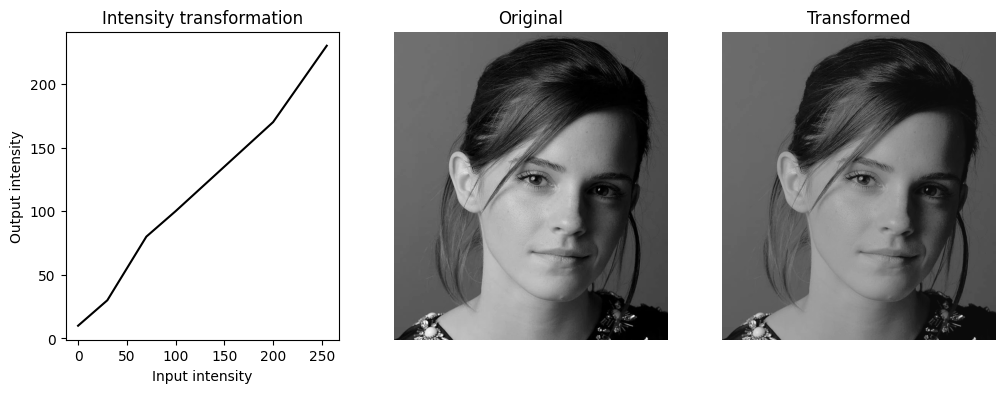

In [18]:
breakpoints = [      #my break points
    [0,   10],
    [30, 30],            #keep hair looking pleasant black
    [70, 80],
    [100, 100],
    [200, 170],          #left side of the face more bright. I reduced it.
    [255, 230],
]

transformed = intensity_transform(img_arr, breakpoints)

bp = np.array(breakpoints)         #plot transformation graph

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(bp[:, 0], bp[:, 1], color='black')
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity transformation')
axes[1].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original')
axes[1].axis('off')
axes[2].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Transformed')
axes[2].axis('off')
plt.show()

Discrete transforms introduce non pleasing outputs. So I go through smoothly continuous transform to adjust brightness of the face trying to keep hair looking black as before. 

2. White matter , Gray matter of the brain

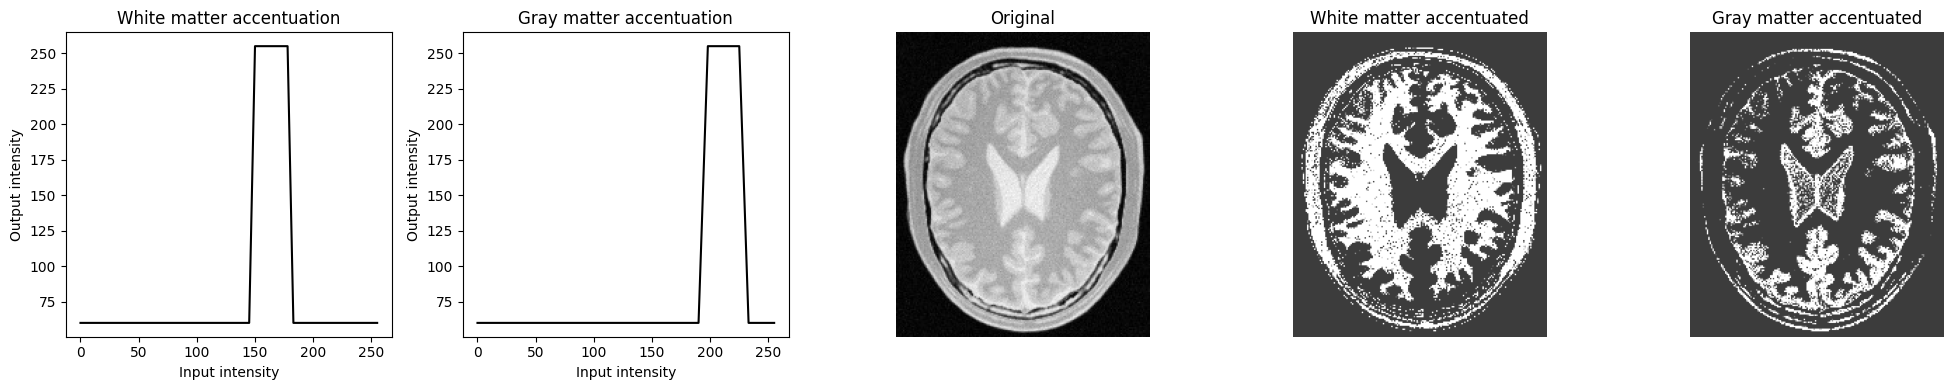

In [19]:
wm_breakpoints = [
    [0,   60],
    [145, 60],
    [150, 255],
    [178, 255],
    [183, 60],
    [255, 60],
]

gm_breakpoints = [
    [0,   60],
    [190, 60],
    [198, 255],
    [225, 255],
    [233, 60],
    [255, 60],
]
img = Image.open("brain_2.jpg").convert("L")
arr = np.array(img)
wm_img = intensity_transform(arr, wm_breakpoints)
gm_img = intensity_transform(arr, gm_breakpoints)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (bp, name) in zip(axes[:2], [(wm_breakpoints, 'White matter'), (gm_breakpoints, 'Gray matter')]):
    bp_arr = np.array(bp)
    ax.plot(bp_arr[:, 0], bp_arr[:, 1], color='black')
    ax.set_xlabel('Input intensity')
    ax.set_ylabel('Output intensity')
    ax.set_title(f'{name} accentuation')

axes[2].imshow(arr, cmap='gray', vmin=0, vmax=255); axes[2].set_title('Original'); axes[2].axis('off')
axes[3].imshow(wm_img, cmap='gray', vmin=0, vmax=255); axes[3].set_title('White matter accentuated'); axes[3].axis('off')
axes[4].imshow(gm_img, cmap='gray', vmin=0, vmax=255); axes[4].set_title('Gray matter accentuated'); axes[4].axis('off')

plt.tight_layout()
plt.show()

Found white matter represents nearly 150 - 180 intensity range and gray matter represent 200 - 225 intensity range. So apply window on each region to extract details on than range while all other intensities reduce to dark 60 intensity. 

3. Gamma correction and histogram

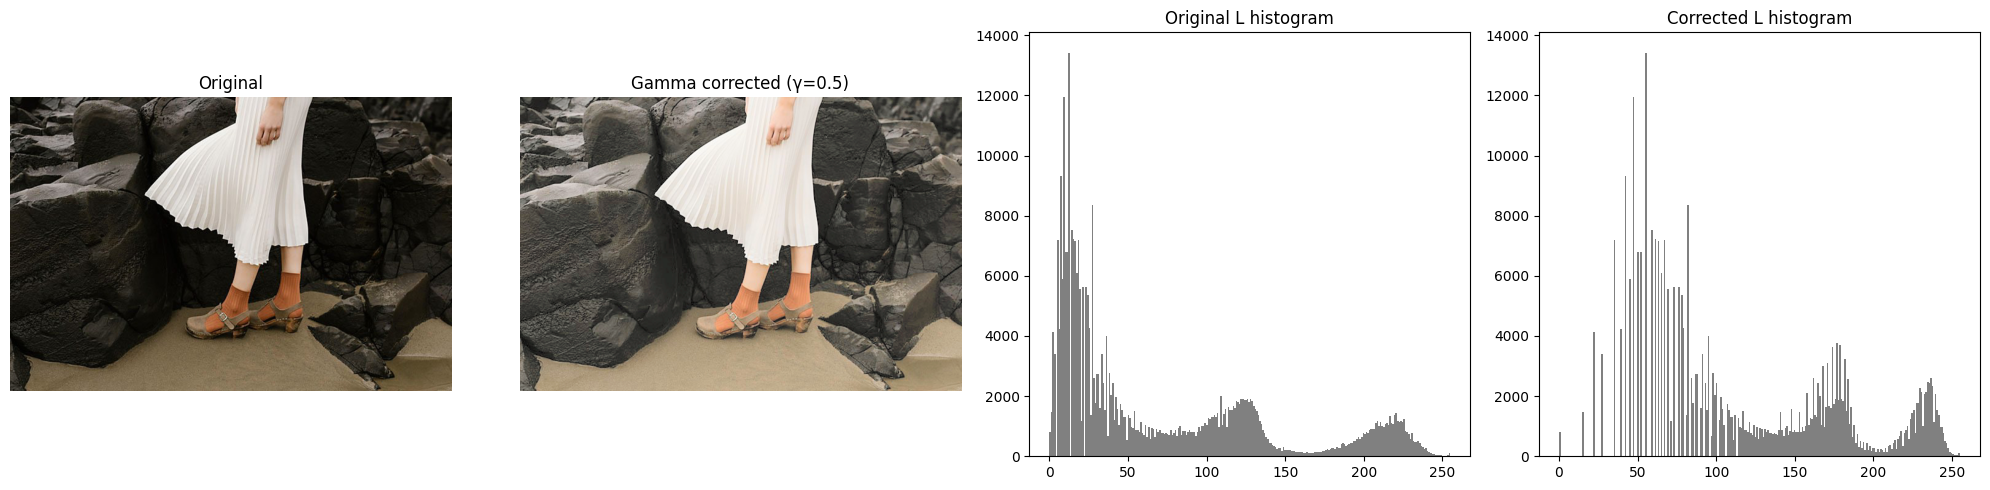

In [20]:
import cv2
img = cv2.imread('stonewhite_3.jpg')

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB) #convert to L*a*b* and channel split
L, a, b = cv2.split(lab)

gamma = 0.5   # gamma < 1 , to L 
L_norm = L.astype(np.float64) / 255.0
L_gamma = np.power(L_norm, gamma) * 255.0
L_gamma = L_gamma.astype(np.uint8)

lab_corrected = cv2.merge([L_gamma, a, b])   #corrected L merge back
img_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_corrected, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma corrected (γ={gamma})')
axes[1].axis('off')
axes[2].hist(L.ravel(), bins=256, range=(0, 255), color='gray')
axes[2].set_title('Original L histogram')
axes[3].hist(L_gamma.ravel(), bins=256, range=(0, 255), color='gray')
axes[3].set_title('Corrected L histogram')
plt.tight_layout()
plt.show()

Gamma corection intend to modify image brightness. So L plane which represent lightness of the pixel to apply histogram while preventing a and b planes same as before. Gamma value choose as 0.5 (< 1) value since original image contain relatively dark regions. So histogram expand and shift toward this dark region to bit bright region. 

4. Intensity Transform to saturation plane

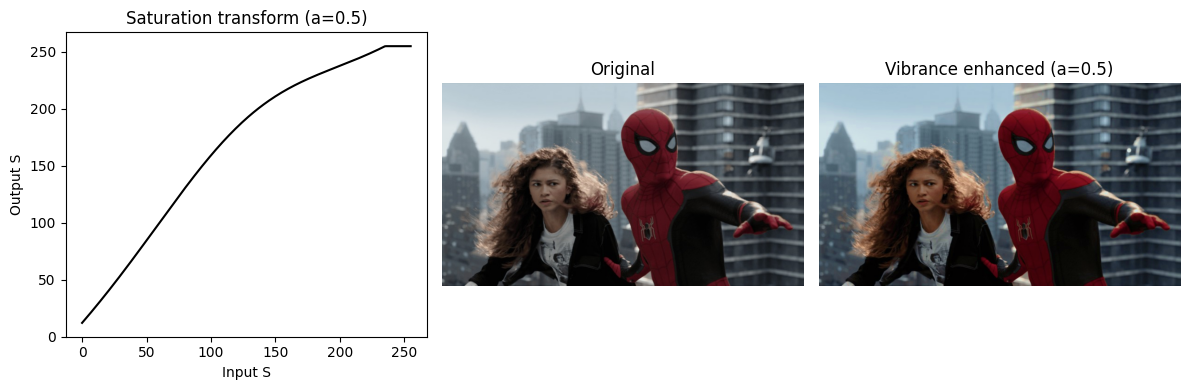

In [22]:
img = cv2.imread('spiderman_4.jpeg')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)     #split to H, S, V planes

def vibrance_transform(x, a, sigma=70):   #define the vibrance transform func.
    x = x.astype(np.float64)
    boosted = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    return np.clip(boosted, 0, 255)

a = 0.5
S_new = vibrance_transform(S, a).astype(np.uint8) #apply transform to S plane

hsv_new = cv2.merge([H, S_new, V])   #recombine H, new S and V
img_new = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2BGR)   #back to BGR

x = np.arange(256)
curve = vibrance_transform(x, a)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(x, curve, color='black')
axes[0].set_xlabel('Input S')
axes[0].set_ylabel('Output S')
axes[0].set_title(f'Saturation transform (a={a})')
axes[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Original')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img_new, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Vibrance enhanced (a={a})')
axes[2].axis('off')
plt.tight_layout()
plt.show()

In HSV planes, Saturation directly control color intensity. So modify S plane increase vibrance while keeping hue and brightness same as before. a= 0.5 choose since it provide noticable but visually pleasing saturation increase. Here transformed values are limited to 255 prevent overfl0w. 

5. Histogram Equalization

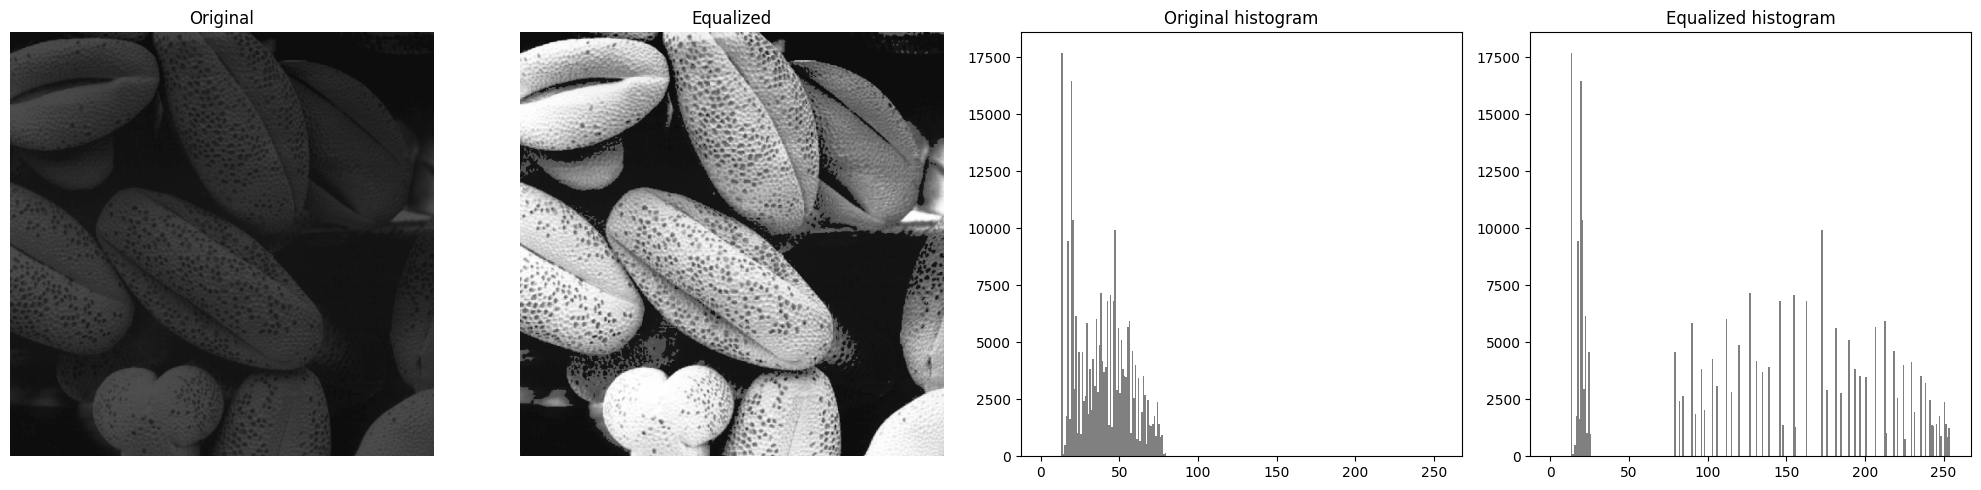

In [23]:
def my_hist_equalize(img):
    img = np.asarray(img)
    hist = np.bincount(img.ravel(), minlength=256) #histogram
    cdf = np.cumsum(hist) #CDF
    cdf_normalized = (            #normalize CDF
        (cdf - cdf.min()) /
        (cdf.max() - cdf.min()) * 255
    )
    lut = cdf_normalized.astype(np.uint8)

    dark_threshold = 26  #keep very dark pixels unchange.(common histogram at threshhold=0)
    lut[:dark_threshold] = np.arange(dark_threshold)

    equalized = lut[img]     #LUT

    return equalized

img = np.array(Image.open('shells_5.tif'))
eq = my_hist_equalize(img)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(eq, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Equalized')
axes[1].axis('off')
axes[2].hist(img.ravel(), bins=256, range=(0, 255), color='gray')
axes[2].set_title('Original histogram')
axes[3].hist(eq.ravel(), bins=256, range=(0, 255), color='gray')
axes[3].set_title('Equalized histogram')
plt.tight_layout()
plt.show()

Histogram equalizing implemented by calculating histogram and CDF. Normalized CDF to 0- 255 range and used it as a look up table to remap pixel intensities. Here I set a threshold to avoid excessive changes in very black regions, which looking unpleasant and bright spots over dark background with general histogram equalizer. So that's why final histogram plot show same type of spikes as original in dark pixel intensity values. Anyway by set threshold 0 can obtain common equalizer. 

6. Histogram equalization only to the foreground

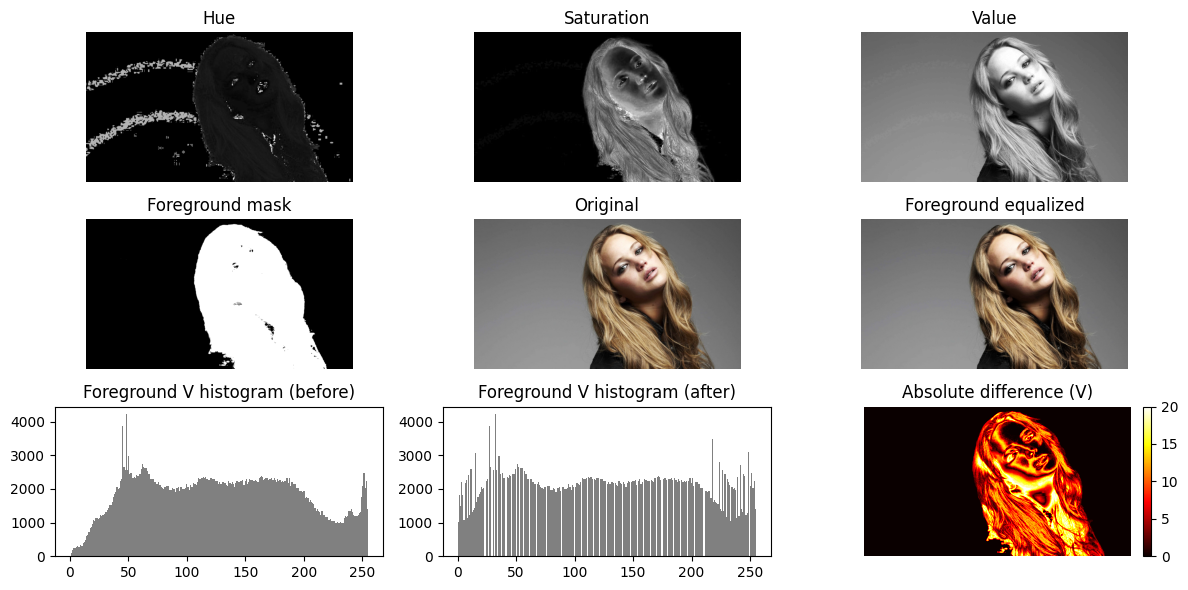

In [26]:
img = cv2.imread('Jennifer_6.jpeg')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)    #convert to HSV
H, S, V = cv2.split(hsv)

_, mask = cv2.threshold(S, 15, 255, cv2.THRESH_BINARY) #background nearly gray. choose S plane. 
fg_V = cv2.bitwise_and(V, V, mask=mask)
hist_fg = cv2.calcHist([V], [0], mask, [256], [0, 256]).flatten()
n_fg = int(mask.sum() / 255)  

cdf = np.cumsum(hist_fg)
cdf_min = cdf[cdf > 0].min()
lut = np.round((cdf - cdf_min) / (n_fg - cdf_min) * 255).clip(0, 255).astype(np.uint8)
equalized_fg_V = cv2.bitwise_and(lut[V], lut[V], mask=mask)

mask_inv = cv2.bitwise_not(mask)
background_V = cv2.bitwise_and(V, V, mask=mask_inv)
new_V = cv2.add(background_V, equalized_fg_V)

hsv_result = cv2.merge([H, S, new_V])
result = cv2.cvtColor(hsv_result, cv2.COLOR_HSV2BGR)

fig, axes = plt.subplots(3, 3, figsize=(12, 6))
axes[0,0].imshow(H, cmap='gray'); axes[0,0].set_title('Hue'); axes[0,0].axis('off')
axes[0,1].imshow(S, cmap='gray'); axes[0,1].set_title('Saturation'); axes[0,1].axis('off')
axes[0,2].imshow(V, cmap='gray'); axes[0,2].set_title('Value'); axes[0,2].axis('off')
axes[1,0].imshow(mask, cmap='gray'); axes[1,0].set_title('Foreground mask'); axes[1,0].axis('off')
axes[1,1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[1,1].set_title('Original'); axes[1,1].axis('off')
axes[1,2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); axes[1,2].set_title('Foreground equalized'); axes[1,2].axis('off')

# Row 3: histograms (foreground only, before/after) and the difference image
axes[2,0].hist(V[mask > 0].ravel(), bins=256, range=(0, 255), color='gray')
axes[2,0].set_title('Foreground V histogram (before)')

axes[2,1].hist(new_V[mask > 0].ravel(), bins=256, range=(0, 255), color='gray')
axes[2,1].set_title('Foreground V histogram (after)')

diff = cv2.absdiff(V, new_V)
im = axes[2,2].imshow(diff, cmap='hot')
axes[2,2].set_title('Absolute difference (V)')
axes[2,2].axis('off')
fig.colorbar(im, ax=axes[2,2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Here choosed saturation plane under threshold 15 to create mask because we can see clear difference between foreground and background from saturation plane since background nearly gray in original image. Then the resultant mask used to extract only foreground of V (coresponding to brightness) plane and apply histogram equalizing. Can see what are changes through histogram diagram and absolute different. 

7. Sobel Filter

max diff a vs b: 0.0
max diff a vs c: 0.0


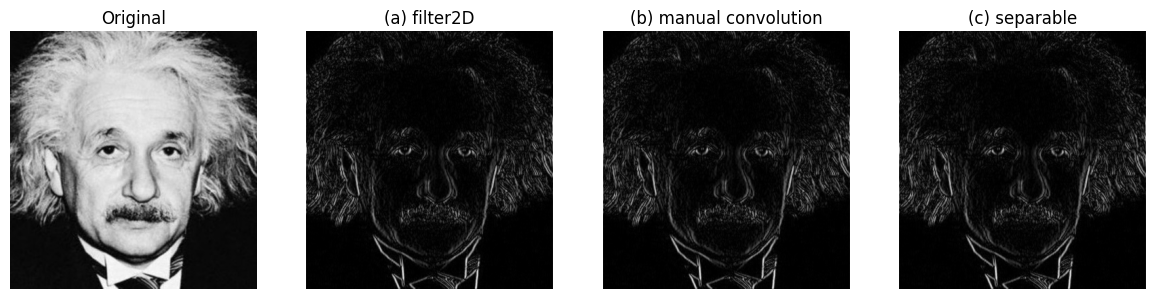

In [8]:
img = cv2.imread('einstein_7.jpeg', cv2.IMREAD_GRAYSCALE).astype(np.float64)
sobel_x = np.array([[1, 0, -1],
                     [2, 0, -2],
                     [1, 0, -1]], dtype=np.float64)

gx_a = cv2.filter2D(img, -1, sobel_x, borderType=cv2.BORDER_CONSTANT)  # cv2,filter2D 

def my_filter2D(image, kernel):    # manual convolution function
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    out = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)
    return out

gx_b = my_filter2D(img, sobel_x)

col = np.array([1, 2, 1], dtype=np.float64)   # vertical kernel
row = np.array([1, 0, -1], dtype=np.float64)  # horizontal kernel

def my_filter1D(image, kernel_1d, axis):
    kh = len(kernel_1d)
    pad = kh // 2
    out = np.zeros_like(image)
    if axis == 0:  # filter down columns
        padded = np.pad(image, ((pad, pad), (0, 0)), mode='constant')
        for m in range(kh):
            out += kernel_1d[m] * padded[m:m+image.shape[0], :]
    else:  # filter along rows
        padded = np.pad(image, ((0, 0), (pad, pad)), mode='constant')
        for m in range(kh):
            out += kernel_1d[m] * padded[:, m:m+image.shape[1]]
    return out

temp = my_filter1D(img, col, axis=0)   # step 1: vertical smoothing
gx_c = my_filter1D(temp, row, axis=1)  # step 2: horizontal derivative

# Verify all three match
print("max diff a vs b:", np.abs(gx_a - gx_b).max())
print("max diff a vs c:", np.abs(gx_a - gx_c).max())

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(np.abs(gx_a), cmap='gray'); axes[1].set_title('(a) filter2D'); axes[1].axis('off')
axes[2].imshow(np.abs(gx_b), cmap='gray'); axes[2].set_title('(b) manual convolution'); axes[2].axis('off')
axes[3].imshow(np.abs(gx_c), cmap='gray'); axes[3].set_title('(c) separable'); axes[3].axis('off')
plt.tight_layout()
plt.show()

This sobel filter use to detect intensity changes in vertical direction. Key point I noticed was implement 2D convolution by two 1D filter operations. Here ([1,2,1]^T) performs vertical smoothing, followed by ([1,0,-1]) which calculates the horizontal derivative. And finally evaluate and find all 3 methods are identical. 

8. Zoom Images

im01small.png -> nearest SSD=0.0121, bilinear SSD=0.0103
im02small.png -> nearest SSD=0.0042, bilinear SSD=0.0029
im03small.png -> nearest SSD=0.0077, bilinear SSD=0.0059
im04small.jpg -> nearest SSD=0.0053, bilinear SSD=0.0046
im04.jpg -> nearest SSD=0.1060, bilinear SSD=0.1044


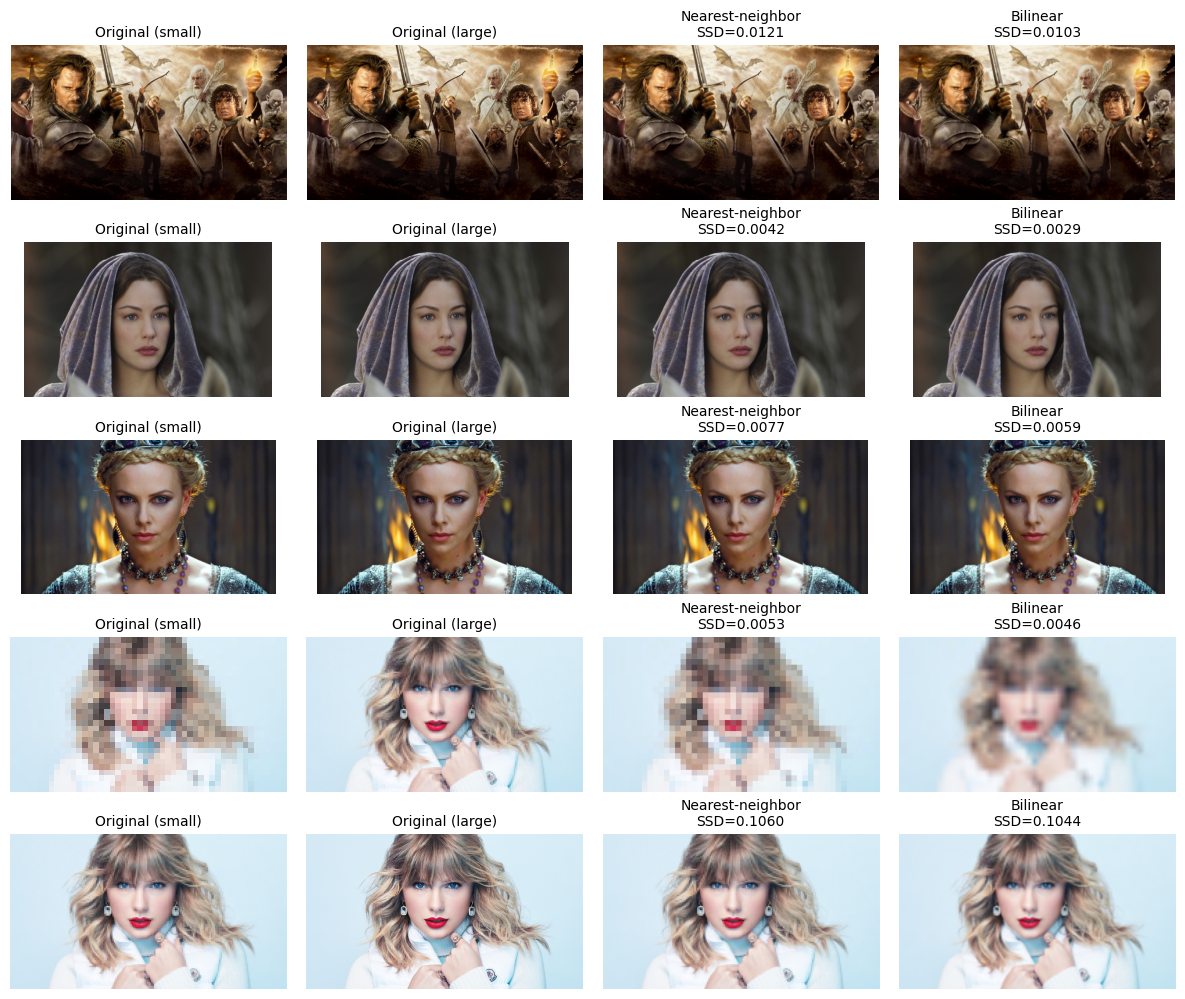

In [9]:
def zoom_image(img, s, method='nearest'):      #zoom function
    img = np.asarray(img, dtype=np.float64)
    if img.ndim == 2:
        img = img[:, :, np.newaxis]
        squeeze = True
    else:
        squeeze = False

    H, W, C = img.shape
    new_H, new_W = int(round(H * s)), int(round(W * s))
    out = np.zeros((new_H, new_W, C), dtype=np.float64)

    for i in range(new_H):
        for j in range(new_W):
            y = (i + 0.5) / s - 0.5
            x = (j + 0.5) / s - 0.5

            if method == 'nearest':
                yi = min(max(int(round(y)), 0), H - 1)
                xi = min(max(int(round(x)), 0), W - 1)
                out[i, j] = img[yi, xi]

            elif method == 'bilinear':
                y0 = int(np.floor(y)); x0 = int(np.floor(x))
                y1, x1 = y0 + 1, x0 + 1
                dy, dx = y - y0, x - x0

                y0c, y1c = min(max(y0,0),H-1), min(max(y1,0),H-1)
                x0c, x1c = min(max(x0,0),W-1), min(max(x1,0),W-1)

                top = img[y0c, x0c] * (1 - dx) + img[y0c, x1c] * dx
                bottom = img[y1c, x0c] * (1 - dx) + img[y1c, x1c] * dx
                out[i, j] = top * (1 - dy) + bottom * dy

    out = np.clip(out, 0, 255).astype(np.uint8)
    return out[:, :, 0] if squeeze else out

def normalized_ssd(img1, img2):         #normalized ssd 
    h = min(img1.shape[0], img2.shape[0])
    w = min(img1.shape[1], img2.shape[1])
    img1 = img1[:h, :w].astype(np.float64)
    img2 = img2[:h, :w].astype(np.float64)
    ssd = np.sum((img1 - img2) ** 2)
    norm = np.sqrt(np.sum(img1**2) * np.sum(img2**2))
    return ssd / norm

image_pairs = [
    ('im01small.png', 'im01.png'),
    ('im02small.png', 'im02.png'),
    ('im03small.png', 'im03.png'),
    ('im04small.jpg', 'im04.jpg'),
    ('im04.jpg',      'im05.jpg'),   
]

zoom_factor = 4
results = [] 

for small_path, large_path in image_pairs:
    small = np.array(Image.open(small_path))
    large = np.array(Image.open(large_path))

    zoomed_nn = zoom_image(small, zoom_factor, method='nearest')
    zoomed_bl = zoom_image(small, zoom_factor, method='bilinear')

    ssd_nn = normalized_ssd(large, zoomed_nn)
    ssd_bl = normalized_ssd(large, zoomed_bl)

    results.append((small, large, zoomed_nn, zoomed_bl, ssd_nn, ssd_bl))
    print(f"{small_path} -> nearest SSD={ssd_nn:.4f}, bilinear SSD={ssd_bl:.4f}")

fig, axes = plt.subplots(5, 4, figsize=(12, 10))
col_titles = ['Original (small)', 'Original (large)', 'Nearest-neighbor', 'Bilinear']

for row, (small, large, zoomed_nn, zoomed_bl, ssd_nn, ssd_bl) in enumerate(results):
    images = [small, large, zoomed_nn, zoomed_bl]
    titles = [
        col_titles[0],
        col_titles[1],
        f'{col_titles[2]}\nSSD={ssd_nn:.4f}',
        f'{col_titles[3]}\nSSD={ssd_bl:.4f}',
    ]
    for col in range(4):
        axes[row, col].imshow(images[col])
        axes[row, col].set_title(titles[col], fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

For nearest neighbor interpolation here each output pixel is assigned the value of the closest input pixel. It is simple but can produce blocky results. Bilinear interpolation use the four neighbouring input pixels and computes a weighted average. So it producing smoother intensity transitions than nearest neighbor. Also we can clearly observe bilinear method accuarate than nearest neighbor by comparing SSD values. Another point is in bilinear method code at image boundaries, coordinates fall outside of valid image range are clipped to nearest valid boundary pixel. 

9. Image enhancing

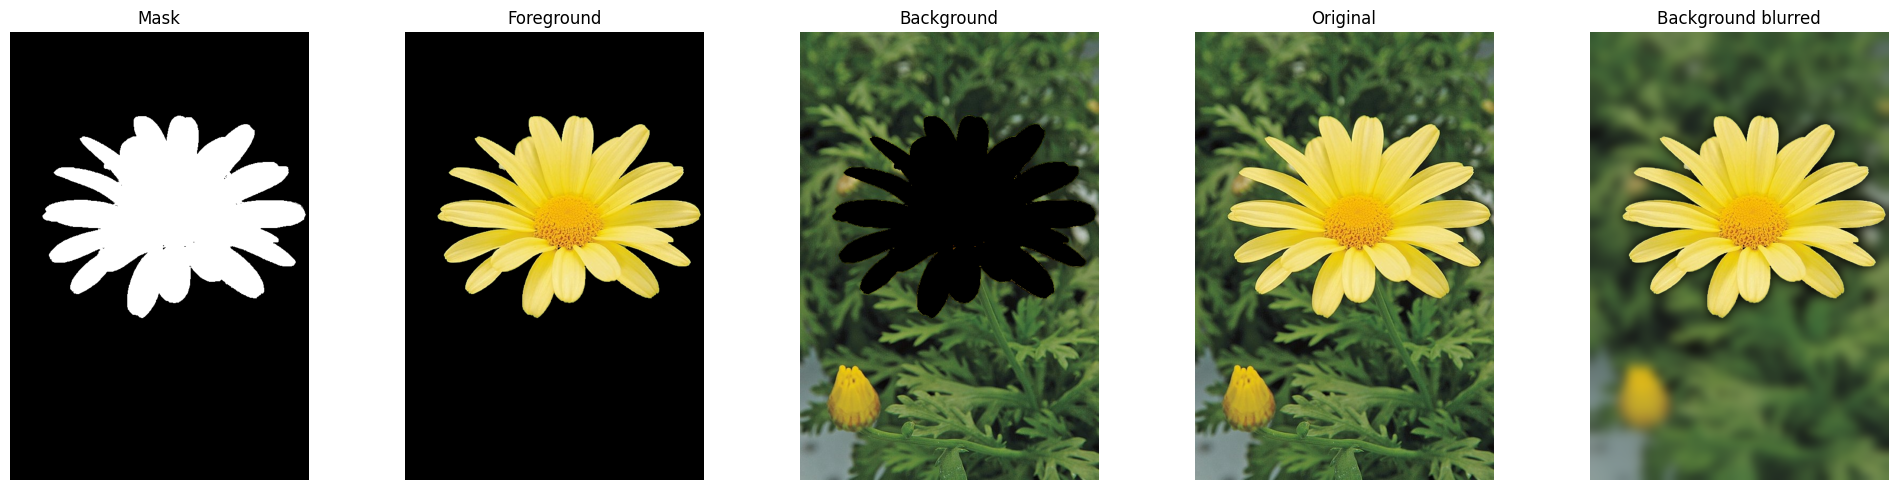

In [10]:
img = cv2.imread('flower_8.jpeg')

mask = np.zeros(img.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
h, w = img.shape[:2]
rect = (int(w*0.05), int(h*0.15), int(w*0.95), int(h*0.55)) #flower roughly in this box
cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8') # 4 value msk to binary
fg = img * mask2[:, :, np.newaxis]    #foreground
bg = img * (1 - mask2[:, :, np.newaxis])   #background

bg_only = img * (1 - mask2[:, :, np.newaxis])   #want blur background only 
blurred_bg = cv2.GaussianBlur(bg_only, (0, 0), sigmaX=10)  #can adjust how much blur by change sigmaX
fg_only = img * mask2[:, :, np.newaxis]
result = (fg_only + blurred_bg * (1 - mask2[:, :, np.newaxis])).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes[0].imshow(mask2 * 255, cmap='gray'); axes[0].set_title('Mask'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(fg, cv2.COLOR_BGR2RGB)); axes[1].set_title('Foreground'); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)); axes[2].set_title('Background'); axes[2].axis('off')
axes[3].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[3].set_title('Original'); axes[3].axis('off')
axes[4].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); axes[4].set_title('Background blurred'); axes[4].axis('off')
plt.tight_layout()
plt.show()

Why dark near edges:  When the "bg_only" has black foreground pixels and the Gaussian blur averages those 0 valued pixels (black color) with nearby background pixels. This lower the background intensity near the flower edges and producing some dark halo along the boundary.

I set rectangle to capture only flower, not with the flower bud. Then split foreground flower with grabcut and created mask. Here key point is I apply gaussian blur to background with black foreground masked flower. But we can introduce blur on original image too and paste flower on this too if need. Anyway if I did that I get output with slightly yellow color near edges of the flower instead dark near edges. 

10. Bilateral Filter

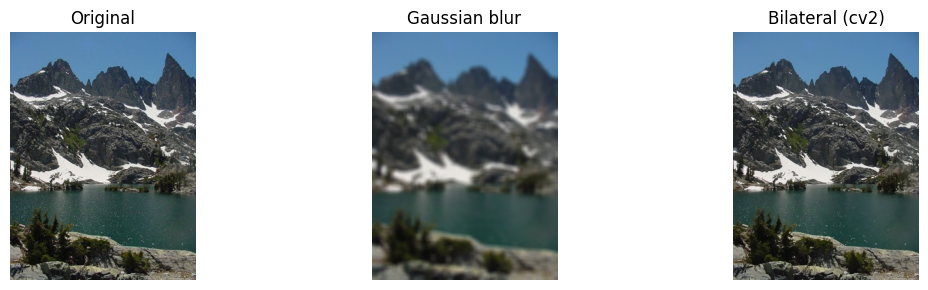

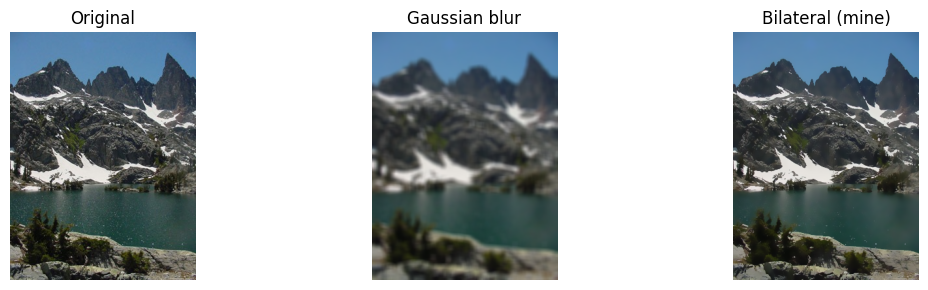

MSE between cv2 and my bilateral filter: 23.908
PSNR between cv2 and my bilateral filter: 34.35 dB


In [11]:
img = cv2.imread('minaret_lake_9.jpeg')

sigma_s = 5  # spatial standard deviation (how far pixels can influence each other)
sigma_r = 20 # range/intensity standard deviation (how similar pixels must be to blend)
d = 9        # neighborhood diameter
bilateral_cv = cv2.bilateralFilter(img, d, sigma_r, sigma_s) #opencv bilateral filter
gaussian = cv2.GaussianBlur(img, (d, d), sigmaX=sigma_s)  #gaussian blur

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB)); axes[1].set_title('Gaussian blur'); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(bilateral_cv, cv2.COLOR_BGR2RGB)); axes[2].set_title('Bilateral (cv2)'); axes[2].axis('off')
plt.tight_layout()
plt.show()

def my_bilateral_filter(img, d, sigma_s, sigma_r): #manual bilateral filter
    img = img.astype(np.float64)
    H, W, C = img.shape
    radius = d // 2
    padded = np.pad(img, ((radius, radius), (radius, radius), (0, 0)), mode='reflect')

    output = np.zeros_like(img)
    weight_sum = np.zeros((H, W, C))

    for dy in range(-radius, radius + 1):           #loop over kernel offsets only
        for dx in range(-radius, radius + 1):
            spatial_w = np.exp(-(dx**2 + dy**2) / (2 * sigma_s**2))
            shifted = padded[radius+dy:radius+dy+H, radius+dx:radius+dx+W, :]
            diff = shifted - img
            range_w = np.exp(-(diff**2) / (2 * sigma_r**2))
            w = spatial_w * range_w
            output += w * shifted
            weight_sum += w

    output = output / weight_sum
    return np.clip(output, 0, 255).astype(np.uint8)

bilateral_mine = my_bilateral_filter(img, d, sigma_s, sigma_r)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB)); axes[1].set_title('Gaussian blur'); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(bilateral_mine, cv2.COLOR_BGR2RGB)); axes[2].set_title('Bilateral (mine)'); axes[2].axis('off')
plt.tight_layout()
plt.show()

def psnr(a, b):       #for quantitative comparison
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

mse_val = np.mean((bilateral_cv.astype(np.float64) - bilateral_mine.astype(np.float64)) ** 2)
psnr_val = psnr(bilateral_cv, bilateral_mine)
print(f"MSE between cv2 and my bilateral filter: {mse_val:.3f}")
print(f"PSNR between cv2 and my bilateral filter: {psnr_val:.2f} dB")

Here spartial sigma controls how far away a pixel can be contribute to smoothing. And sigma_r (range/intensity sigma) controlls how different in brightness of two pixels can mix. If sigma_r large more smoothing over edges. Also diameter represent the neighborhood window size. It should be large enough to cover the spartial effect of sigma_s. I run separate for loop structure on python IDE and tune the sigma values which give best quantitative results with low MSE and high PSNR. 
Here function name as my_bilateral_filter use a trick, which loop over the kernal, not the image. This introduce significant fast than naive bilateral filter which loop over every pixel on the image. It loops only over the kernel offsets (dy, dx), is just 9 × 9 = 81 iterations total. And for each offset it shifts the entire image at once and lets NumPy do the pixel by pixel math in fast using compiled C code. NumPy run these in optimized C loops which is faster than pure Python loops.

Git: https://github.com/minsarapasindu2003-del/CV_assignment_01